# NYC Taxi Pickup Demand — v2 Tuned Model

- Caleb Solomons
- Mubeen Yaqub
- Mai Lam
- Anh Minh Tran

**DSCI 592 Capstone — Team GridRunners**
**Target:** `demand_count` — count of pickups per `(PU_borough, date, hour)` bucket (Poisson regression)

The three other models predict a trip-level quantity (fare, duration, tip probability) directly observable on each row of the parquet. Demand is a **zone-time aggregate** — there's no trip-level "demand" column to read, so we have to **derive the target** by counting pickups per `(PU_borough, date, hour)` bucket and joining that count back to every trip row.

1. **Target derivation cell** — Groups the cleaned parquet by `(PU_borough, date, hour)`, counts pickups, joins the count back as `demand_count`.

2. **Poisson regression head** — `count:poisson` objective with `poisson-nloglik` eval metric. Counts are non-negative integers with a right-skewed distribution; Poisson regression's log link respects the non-negativity and matches the count generative story. The predicted output is in the original count scale (XGBoost applies the inverse link automatically), so the Streamlit wrapper consumes it identically to `reg:squarederror` output.

3. **Group-aware CV (Section 14)** — `GroupKFold` keyed on `(PU_borough, date, hour)` instead of plain `KFold`. Because every trip in a bucket shares the same target value, plain random K-fold would leak the target across folds and produce misleadingly optimistic metrics. Group K-fold guarantees each unique bucket appears entirely in one fold.

**Feature schema is unchanged** — same 16 columns as the other three models, same dtypes, same order. This is non-negotiable because the Streamlit app feeds one feature row to all four models. Trip-level features (DO_borough, trip_distance, haversine_mi, manhattan_mi, passenger_count, VendorID, RatecodeID) don't carry information about *other* trips happening at the same zone/time — the booster will treat them as noise and split on them rarely. Feature importance will pin pickup_hour, PU_borough, pickup_dow, is_weekend, weather, and event flags as the meaningful signal.

Output: `xgb_v2_demand.json` — loaded directly by `gridrunners_demo.py` via `predict_demand`.

## 1. Setup

In [ ]:
!pip -q install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.3 MB/s eta 0:00:00


In [ ]:
import json
import math
import warnings
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold, GroupShuffleSplit, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb

import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["savefig.bbox"] = "tight"
sns.set_style("whitegrid")

print(f"pandas {pd.__version__} | numpy {np.__version__} | xgboost {xgb.__version__} | optuna {optuna.__version__}")

pandas 2.2.2 | numpy 2.0.2 | xgboost 3.2.0 | optuna 4.8.0


## 2. Config Tuning


- `MIN_BUCKET_SIZE` — minimum trips per (PU_borough, date, hour) bucket for it to count. Default 1 (keep all buckets, including legitimate low-demand cases like Staten Island at 3am).
- `BUCKET_FREQ` — temporal resolution. Default `"H"` (hourly). Switch to `"30min"` for half-hour resolution at the cost of higher target variance per bucket.

In [ ]:
SAMPLE_SIZE = 1_500_000
TUNING_SAMPLE = 250_000
USE_FULL_DATASET = False

N_TRIALS = 30
CV_FOLDS = 5

DIST_MIN, DIST_MAX = 0.3, 50.0

MIN_BUCKET_SIZE = 1
BUCKET_FREQ = "H"

ENABLE_WEATHER_JOIN = True
ENABLE_EVENT_FLAGS = True
ENABLE_DISTANCE_PROXIES = True

XGB_DEVICE = "cuda"

## 3. Mount Drive & Set Paths

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

DRIVE_BASE  = Path("/content/drive/MyDrive/DSCI 592")
DATA_PATH   = Path("/content/drive/MyDrive/DSCI 592/2023_Yellow_Taxi_Cleaned.parquet")

OUTPUT_DIR  = DRIVE_BASE / "v2_tuned_demand"
FIGURE_DIR  = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"

for d in (OUTPUT_DIR, FIGURE_DIR, METRICS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Reading data from : {DATA_PATH}")
print(f"Saving outputs to : {OUTPUT_DIR}")

Mounted at /content/drive
Reading data from : /content/drive/MyDrive/DSCI 592/2023_Yellow_Taxi_Cleaned.parquet
Saving outputs to : /content/drive/MyDrive/DSCI 592/v2_tuned_demand


## 4. Load Data & Inspect Columns

In [ ]:
df_full = pd.read_parquet(DATA_PATH)

print(f"Full dataset shape : {df_full.shape[0]:,} rows × {df_full.shape[1]} cols")
print(f"Memory footprint : {df_full.memory_usage(deep=True).sum() / 1e9:.2f} GB\n")
print("Columns and dtypes:")

print(df_full.dtypes.to_string())

Full dataset shape : 37,017,621 rows × 35 cols
Memory footprint   : 29.12 GB

Columns and dtypes:
VendorID                          int64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
trip_duration_min               float64
speed_mph                       float64
pickup_hour                       int32
pickup_dow            

## 5. Column Mapping & Leakage Discipline

- Trip-level features (`trip_distance`, `DO_borough`, `passenger_count`, distance proxies, `VendorID`, `RatecodeID`) carry no information about *other* trips in the same bucket. The booster will treat them as noise. Kept only to match the Streamlit feature contract.
- The actual signal lives in: `PU_borough`, `pickup_hour`, `pickup_dow`, `is_weekend`, `is_us_holiday`, `is_nyc_event`, `is_rainy`, `temp_f`, `precip_in`. These are constant across all trips in a bucket and *should* dominate feature importance.

**Target swap:** `demand_count` — derived in Section 11 by aggregation. Not a column in the parquet yet; will create it.

In [ ]:
COL = {
    "target":         "demand_count",   # <<< derived in Section 11
    "trip_distance":  "trip_distance",
    "passengers":     "passenger_count",
    "hour":           "pickup_hour",
    "dow":            "pickup_dow",
    "weekend":        "is_weekend",
    "pu_borough":     "PU_borough",
    "do_borough":     "DO_borough",
    "vendor":         "VendorID",
    "pickup_dt":      "tpep_pickup_datetime",
    "ratecode":       "RatecodeID",
}


NUMERIC_BASE = [COL["trip_distance"], COL["passengers"]]

CATEGORICAL_BASE = [COL["hour"], COL["dow"], COL["weekend"],
                    COL["pu_borough"], COL["do_borough"], COL["vendor"],
                    COL["ratecode"]]

TARGET = COL["target"]

ENG_NUMERIC     = []
ENG_CATEGORICAL = []


needed = set(NUMERIC_BASE + CATEGORICAL_BASE + [COL["pickup_dt"]])
missing = sorted(needed - set(df_full.columns))

if missing:
    raise KeyError(f"Missing columns — fix COL mapping: {missing}")

print("All expected source columns present. Proceeding.")

All expected source columns present. Proceeding.


## 6. Filter

Lighter than fare/duration filter — no target bounds because the target doesn't exist yet (derived it in Section 11). Distance bounds match the other models for training-distribution consistency.

In [ ]:
mask = (
    df_full[COL["trip_distance"]].between(DIST_MIN, DIST_MAX)
    & df_full[COL["ratecode"]].notna()
    & df_full[NUMERIC_BASE + CATEGORICAL_BASE + [COL["pickup_dt"]]].notna().all(axis=1)
)

df_clean = df_full.loc[mask, NUMERIC_BASE + CATEGORICAL_BASE + [COL["pickup_dt"]]].copy()
df_clean[COL["ratecode"]] = df_clean[COL["ratecode"]].astype("int8")

dropped = (~mask).sum()

print(f"Rows dropped by filter : {dropped:,} ({dropped / len(df_full):.2%})")
print(f"Rows remaining         : {len(df_clean):,}")

Rows dropped by filter : 1,922,882 (5.19%)
Rows remaining         : 35,094,739


## 7. Feature Engineering — Pillar 1: Event-Day Flags

For demand specifically, holidays and events drive the largest swings in pickup volume — NYE in Times Square, the Marathon, Thanksgiving Parade all collapse normal traffic patterns and replace them with event-driven surges in specific zones.

In [ ]:
from pandas.tseries.holiday import USFederalHolidayCalendar

holidays_2023 = pd.DatetimeIndex(
    USFederalHolidayCalendar().holidays(start="2023-01-01", end="2023-12-31")
).normalize()

NYC_EVENTS_2023 = pd.to_datetime([
    "2023-06-25",  # NYC Pride March
    "2023-09-10",  # US Open men's final
    "2023-11-05",  # NYC Marathon
    "2023-11-23",  # Macy's Thanksgiving Day Parade
    "2023-12-31",  # NYE Times Square
]).normalize()

if ENABLE_EVENT_FLAGS:

    pickup_date = df_clean[COL["pickup_dt"]].dt.normalize()

    df_clean["is_us_holiday"] = pickup_date.isin(holidays_2023).astype("int8")
    df_clean["is_nyc_event"]  = pickup_date.isin(NYC_EVENTS_2023).astype("int8")

    ENG_CATEGORICAL += ["is_us_holiday", "is_nyc_event"]

    print(f"US holiday trips : {df_clean['is_us_holiday'].sum():,} "
          f"({df_clean['is_us_holiday'].mean():.2%})")
    
    print(f"NYC event trips  : {df_clean['is_nyc_event'].sum():,} "
          f"({df_clean['is_nyc_event'].mean():.2%})")
    
else:
    print("Event-day flags disabled via ENABLE_EVENT_FLAGS=False")

US holiday trips : 765,525 (2.18%)
NYC event trips  : 397,305 (1.13%)


## 8. Feature Engineering — Pillar 2: Distance Proxies

Note: distance proxies are essentially **noise** from the demand model's perspective — a single trip's PU -> DO geometry tells you nothing about how many *other* trips are happening at that zone/time. Compute them anyway because the Streamlit app uses one shared feature row across all four models and the schema must match exactly. Expect both `haversine_mi` and `manhattan_mi` to land near-zero in feature importance.

In [ ]:
BOROUGH_CENTROIDS = {
    "Manhattan":      (40.7831, -73.9712),
    "Brooklyn":       (40.6782, -73.9442),
    "Queens":         (40.7282, -73.7949),
    "Bronx":          (40.8448, -73.8648),
    "Staten Island":  (40.5795, -74.1502),
    "EWR":            (40.6895, -74.1745),
}

EARTH_R_MI = 3958.8

def _haversine_vec(lat1, lon1, lat2, lon2):

    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2

    return 2 * EARTH_R_MI * np.arcsin(np.sqrt(a))

if ENABLE_DISTANCE_PROXIES:

    pu = df_clean[COL["pu_borough"]].astype(str)
    do = df_clean[COL["do_borough"]].astype(str)

    pu_lat = pu.map(lambda b: BOROUGH_CENTROIDS.get(b, (np.nan, np.nan))[0]).to_numpy(dtype=float)
    pu_lon = pu.map(lambda b: BOROUGH_CENTROIDS.get(b, (np.nan, np.nan))[1]).to_numpy(dtype=float)
    do_lat = do.map(lambda b: BOROUGH_CENTROIDS.get(b, (np.nan, np.nan))[0]).to_numpy(dtype=float)
    do_lon = do.map(lambda b: BOROUGH_CENTROIDS.get(b, (np.nan, np.nan))[1]).to_numpy(dtype=float)

    df_clean["haversine_mi"] = _haversine_vec(pu_lat, pu_lon, do_lat, do_lon)
    df_clean["manhattan_mi"] = (np.abs(pu_lat - do_lat) * 69.0 + np.abs(pu_lon - do_lon) * 52.5    )

    fb = df_clean[COL["trip_distance"]].to_numpy()

    df_clean["haversine_mi"] = np.where(np.isnan(df_clean["haversine_mi"]), fb, df_clean["haversine_mi"])
    df_clean["manhattan_mi"] = np.where(np.isnan(df_clean["manhattan_mi"]), fb, df_clean["manhattan_mi"])

    ENG_NUMERIC += ["haversine_mi", "manhattan_mi"]

    print(f"haversine_mi  — mean {df_clean['haversine_mi'].mean():.2f} mi, max {df_clean['haversine_mi'].max():.2f} mi")
    print(f"manhattan_mi  — mean {df_clean['manhattan_mi'].mean():.2f} mi, max {df_clean['manhattan_mi'].max():.2f} mi")
    
else:
    print("Distance proxies disabled via ENABLE_DISTANCE_PROXIES=False")

haversine_mi  — mean 1.32 mi, max 49.86 mi
manhattan_mi  — mean 1.69 mi, max 49.86 mi


## 9. Feature Engineering — Pillar 3: Weather Join

For demand specifically, weather has a strong expected effect: rain bumps demand citywide (people switch from walking/biking to taxis), and extreme cold or heat similarly shifts the mode-share toward taxis.

In [ ]:
def _synthetic_nyc_weather(year: int = 2023) -> pd.DataFrame:

    days = pd.date_range(f"{year}-01-01", f"{year}-12-31", freq="D")
    monthly_temp = [32, 35, 43, 53, 63, 72, 78, 76, 69, 58, 47, 37]

    rng = np.random.default_rng(SEED)

    temps   = np.array([monthly_temp[d.month - 1] + rng.normal(0, 4) for d in days])

    precip  = rng.exponential(0.12, size=len(days))
    precip[rng.random(len(days)) < 0.55] = 0.0

    return pd.DataFrame({"date": days.normalize(), "temp_f": temps, "precip_in": precip})

def _fetch_open_meteo(year: int = 2023) -> pd.DataFrame:

    import requests

    url = (
        "https://archive-api.open-meteo.com/v1/archive"
        f"?latitude=40.7831&longitude=-73.9712"
        f"&start_date={year}-01-01&end_date={year}-12-31"
        f"&daily=temperature_2m_mean,precipitation_sum"
        f"&temperature_unit=fahrenheit&precipitation_unit=inch&timezone=America/New_York"
    )

    r = requests.get(url, timeout=20)
    r.raise_for_status()

    j = r.json()["daily"]

    return pd.DataFrame({
        "date": pd.to_datetime(j["time"]).normalize(),
        "temp_f": j["temperature_2m_mean"],
        "precip_in": j["precipitation_sum"],
    })

if ENABLE_WEATHER_JOIN:

    try:

        weather = _fetch_open_meteo(2023)
        source = "Open-Meteo (real)"

    except Exception as e:

        print(f"  Open-Meteo unreachable ({type(e).__name__}); using synthetic climatology.")

        weather = _synthetic_nyc_weather(2023)
        source = "synthetic (fallback)"

    weather["is_rainy"] = (weather["precip_in"] > 0.1).astype("int8")

    # NOTE: unlike the other notebooks, KEEP `_pickup_date` here because
    # we need it as part of the group key in Section 11.

    df_clean["_pickup_date"] = df_clean[COL["pickup_dt"]].dt.normalize()
    df_clean = df_clean.merge(weather, left_on="_pickup_date", right_on="date", how="left")
    df_clean = df_clean.drop(columns=["date"])   # keep _pickup_date for grouping

    ENG_NUMERIC += ["temp_f", "precip_in"]
    ENG_CATEGORICAL += ["is_rainy"]

    print(f"Weather source : {source}")
    print(f"Days joined    : {weather['date'].nunique()} / 365")

else:
    df_clean["_pickup_date"] = df_clean[COL["pickup_dt"]].dt.normalize()

    print("Weather join disabled — kept _pickup_date for grouping.")

Weather source : Open-Meteo (real)
Days joined    : 365 / 365


## 10. Feature Set + Native Categorical Conversion

Must match `ALL_FEATURES` in `gridrunners_demo.py` exactly.

In [ ]:
NUMERIC_FEATURES     = NUMERIC_BASE + ENG_NUMERIC
CATEGORICAL_FEATURES = CATEGORICAL_BASE + ENG_CATEGORICAL
ALL_FEATURES         = NUMERIC_FEATURES + CATEGORICAL_FEATURES

for c in CATEGORICAL_FEATURES:
    df_clean[c] = df_clean[c].astype("category")

print(f"Numeric features      ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"Categorical features  ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"Total feature count   : {len(ALL_FEATURES)}")


EXPECTED = [
    "trip_distance", "passenger_count", "haversine_mi", "manhattan_mi",
    "temp_f", "precip_in",
    "pickup_hour", "pickup_dow", "is_weekend",
    "PU_borough", "DO_borough", "VendorID", "RatecodeID",
    "is_us_holiday", "is_nyc_event", "is_rainy",
]

assert ALL_FEATURES == EXPECTED, (
    f"FEATURE SCHEMA DRIFT — Streamlit will fail at predict time.\n"
    f"  got      : {ALL_FEATURES}\n"
    f"  expected : {EXPECTED}"
)

print("\n✓ Feature schema matches gridrunners_demo.py ALL_FEATURES")

Numeric features      (6): ['trip_distance', 'passenger_count', 'haversine_mi', 'manhattan_mi', 'temp_f', 'precip_in']
Categorical features  (10): ['pickup_hour', 'pickup_dow', 'is_weekend', 'PU_borough', 'DO_borough', 'VendorID', 'RatecodeID', 'is_us_holiday', 'is_nyc_event', 'is_rainy']
Total feature count   : 16

✓ Feature schema matches gridrunners_demo.py ALL_FEATURES


## 11. **Demand Target Aggregation** *(no analog in fare/duration/tip)*

 The target `demand_count` doesn't exist in the parquet — derive it here by:

1. **Forming the group key** — `(PU_borough, _pickup_date, pickup_hour)`. This is the bucket inside which "demand" is well-defined. Granularity is hourly per pickup borough; flip `BUCKET_FREQ` in Section 2 for finer resolution.
2. **Counting trips per bucket** — `groupby(...).size()` gives the pickup count.
3. **Joining the count back to every trip row** — each trip in a bucket inherits the bucket's total count as its training target.

**Why this design** (rather than aggregating to one row per bucket): the Streamlit app passes the same trip-level feature row to all four models. If collapsed the demand training data to one row per bucket, the feature schema would diverge and need a separate inference path. By keeping trip-level rows with a bucket-level target, we get one model that consumes the same feature row as fare/duration/tip — the booster just learns to mostly ignore the trip-specific columns.

**The downside, and the fix** (Section 14): every trip in a bucket shares the same target value. Plain random K-fold would put trips from the same bucket in both train and test, leaking the target perfectly. We use `GroupKFold` keyed on the bucket ID to prevent this. Same key gets used for the held-out test split. *Without group-aware splitting, the reported metrics would be dishonest.* This is the single most important correctness move in the notebook.

In [ ]:
df_clean["_bucket_key"] = (
    df_clean[COL["pu_borough"]].astype(str)
    + "|"
    + df_clean["_pickup_date"].astype(str)
    + "|"
    + df_clean[COL["hour"]].astype(str)
)

# If using sub-hourly buckets, recompute the hour-component

if BUCKET_FREQ != "H":
    bucket_floor = df_clean[COL["pickup_dt"]].dt.floor(BUCKET_FREQ)

    df_clean["_bucket_key"] = (
        df_clean[COL["pu_borough"]].astype(str)
        + "|"
        + bucket_floor.astype(str)
    )


print(f"Computing pickup counts per (PU_borough × {BUCKET_FREQ}) bucket...")

bucket_counts = df_clean.groupby("_bucket_key", observed=True).size().rename(TARGET)

print(f"Unique buckets : {len(bucket_counts):,}")
print(f"\nBucket count distribution (pickups per bucket):")
print(bucket_counts.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).round(1).to_string())


if MIN_BUCKET_SIZE > 1:

    keep_buckets = bucket_counts[bucket_counts >= MIN_BUCKET_SIZE].index
    before = len(df_clean)
    df_clean = df_clean[df_clean["_bucket_key"].isin(keep_buckets)].copy()
    bucket_counts = bucket_counts.loc[keep_buckets]

    print(f"\nFiltered buckets with < {MIN_BUCKET_SIZE} trips: "
          f"{before - len(df_clean):,} rows dropped, {len(keep_buckets):,} buckets remain")


df_clean = df_clean.merge(bucket_counts, left_on="_bucket_key", right_index=True, how="left")

assert df_clean[TARGET].notna().all(), "Target join failed — null values present"

print(f"\nTarget `demand_count` joined to all {len(df_clean):,} trip rows")
print(f"Target stats: mean {df_clean[TARGET].mean():.1f}, median {df_clean[TARGET].median():.0f}, "
      f"min {df_clean[TARGET].min()}, max {df_clean[TARGET].max()}")

Computing pickup counts per (PU_borough × H) bucket...
Unique buckets : 43,355

Bucket count distribution (pickups per bucket):
count    43355.0
mean       809.5
std       1689.6
min          1.0
10%          2.0
25%         10.0
50%         36.0
75%        499.0
90%       4097.8
99%       6584.5
max       9598.0

Target `demand_count` joined to all 35,094,739 trip rows
Target stats: mean 4335.9, median 4762, min 1, max 9598


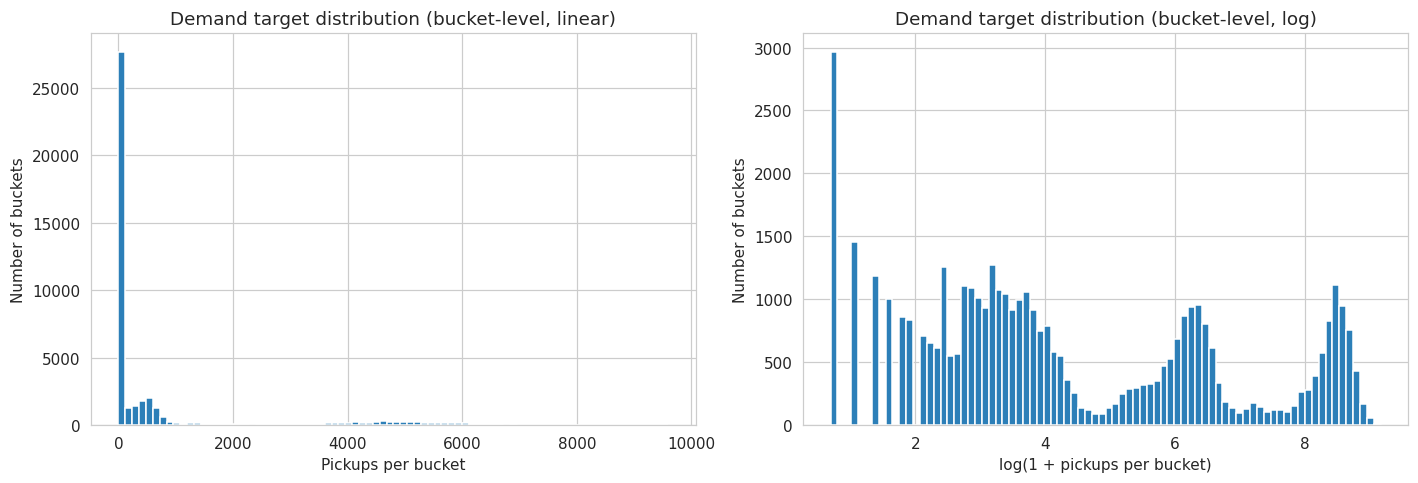

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# linear scale

axes[0].hist(bucket_counts, bins=80, color="#2c7fb8", edgecolor="white")
axes[0].set_xlabel("Pickups per bucket")
axes[0].set_ylabel("Number of buckets")
axes[0].set_title("Demand target distribution (bucket-level, linear)")

# log scale

axes[1].hist(np.log1p(bucket_counts), bins=80, color="#2c7fb8", edgecolor="white")
axes[1].set_xlabel("log(1 + pickups per bucket)")
axes[1].set_ylabel("Number of buckets")
axes[1].set_title("Demand target distribution (bucket-level, log)")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "v2_demand_target_distribution.png")

plt.show()

## 12. Stratified Samples — Tuning + Evaluation

Sampling strategy is slightly different from the other notebooks: we want to preserve the bucket structure during sampling so GroupKFold has enough unique buckets per fold.

Approach: stratify on `pickup_hour × PU_borough` as before, but track the `_bucket_key` for later group-aware splitting.

In [ ]:
df_clean["_strat"] = (df_clean[COL["hour"]].astype(str) + "|" + df_clean[COL["pu_borough"]].astype(str))

def _stratified_sample(df: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:

    frac = min(1.0, n / len(df))
    out = df.groupby("_strat").sample(frac=frac, random_state=seed)

    return out.drop(columns=["_strat"]).reset_index(drop=True)

eval_sample = _stratified_sample(df_clean, SAMPLE_SIZE,   seed=SEED)
tune_sample = _stratified_sample(df_clean, TUNING_SAMPLE, seed=SEED + 1)

print(f"Evaluation sample : {len(eval_sample):,} rows, "
      f"{eval_sample['_bucket_key'].nunique():,} unique buckets")

print(f"Tuning sample     : {len(tune_sample):,} rows, "
      f"{tune_sample['_bucket_key'].nunique():,} unique buckets")

Evaluation sample : 1,499,992 rows, 29,133 unique buckets
Tuning sample     : 249,994 rows, 18,807 unique buckets


## 13. Hyperparameter - Optuna over XGBoost

1. **Objective: `count:poisson`**. Counts are non-negative integers — using `reg:squarederror` works but doesn't respect that structure (predictions can go slightly negative; large counts dominate the squared error). Poisson regression with a log link is the principled choice: models $P(\text{count} = k) = \frac{e^{-\lambda} \lambda^k}{k!}$ where $\lambda = e^{\beta^T x}$, where $\lambda$ is the expected count per bucket and $x$ is the feature vector. XGBoost handles the link function internally; `Booster.predict` returns the prediction in the original count scale (after applying $e^{\cdot}$), so the Streamlit wrapper sees a count and not a log-count.

2. **Eval metric: `poisson-nloglik`**. The proper scoring rule for Poisson regression — the negative log-likelihood of the observed counts under the predicted Poisson distribution. Equivalent to half the Poisson deviance.

3. **Group-aware validation split**. `GroupShuffleSplit` ensures the held-out 20% of each Optuna trial contains only buckets that the training 80% didn't see. Without this, every trial's reported score is inflated by target leakage.

In [ ]:
def objective(trial: optuna.Trial) -> float:

    params = {
        "objective":          "count:poisson",
        "eval_metric":        "poisson-nloglik",
        "tree_method":        "hist",
        "device":             XGB_DEVICE,
        "enable_categorical": True,
        "random_state":       SEED,
        "verbosity":          0,
        # ── searched ── (identical ranges to fare/duration/tip)
        "max_depth":        trial.suggest_int("max_depth", 4, 12),
        "learning_rate":    trial.suggest_float("learning_rate", 1e-2, 3e-1, log=True),
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1500),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
    }

    X = tune_sample[ALL_FEATURES]
    y = tune_sample[TARGET]

    groups = tune_sample["_bucket_key"]


    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)

    tr_idx, va_idx = next(gss.split(X, y, groups=groups))

    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    model = xgb.XGBRegressor(**params, early_stopping_rounds=50, n_jobs=-1)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    preds = model.predict(X_va)

    return float(mean_absolute_error(y_va, preds))


study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=SEED),
    study_name="demand_v2_tuning",
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\n" + "=" * 60)
print(f" OPTUNA — best MAE: {study.best_value:.3f} pickups  (after {N_TRIALS} trials)")
print("=" * 60)

for k, v in study.best_params.items():
    print(f"  {k:<20} {v}")

with open(METRICS_DIR / "optuna_best_params.json", "w") as f:
    
    json.dump({"best_mae": study.best_value, "best_params": study.best_params,
               "n_trials": N_TRIALS, "tuning_sample_size": len(tune_sample)}, f, indent=2)

  0%|          | 0/30 [00:00<?, ?it/s]


 OPTUNA — best MAE: 228.279 pickups  (after 30 trials)
  max_depth            5
  learning_rate        0.2923054009644287
  n_estimators         1331
  min_child_weight     7
  subsample            0.6125516819803675
  colsample_bytree     0.7157343310557601
  reg_alpha            0.0014942673839468035
  reg_lambda           0.1964101424424174
  gamma                4.990699946844692


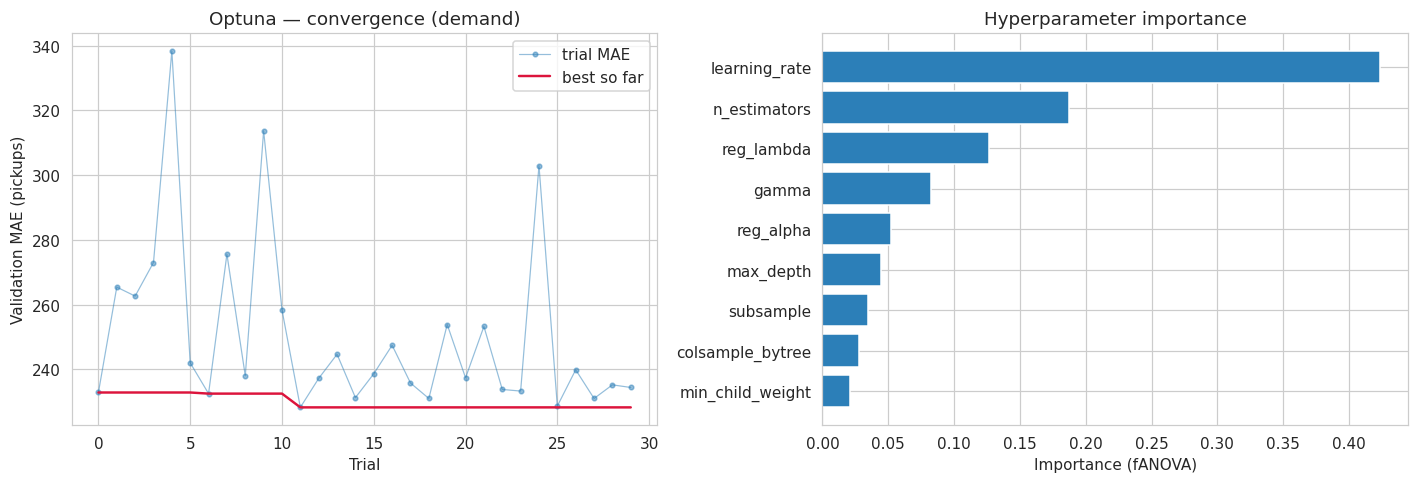

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

trials_df = study.trials_dataframe()

axes[0].plot(trials_df["number"], trials_df["value"], marker="o", markersize=3,
             linewidth=0.8, color="#2c7fb8", alpha=0.5, label="trial MAE")
axes[0].plot(trials_df["number"], trials_df["value"].cummin(),
             color="crimson", linewidth=1.6, label="best so far")

axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Validation MAE (pickups)")
axes[0].set_title("Optuna — convergence (demand)")
axes[0].legend(loc="upper right")

try:

    importances = optuna.importance.get_param_importances(study)
    imp_df = pd.Series(importances).sort_values()

    axes[1].barh(imp_df.index, imp_df.values, color="#2c7fb8")
    axes[1].set_xlabel("Importance (fANOVA)")
    axes[1].set_title("Hyperparameter importance")

except Exception as e:
    axes[1].text(0.5, 0.5, f"importance unavailable\n({type(e).__name__})",
                 ha="center", va="center", transform=axes[1].transAxes)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "optuna_search.png")

plt.show()

## 14. Group K-Fold Cross-Validation with Best Params

`GroupKFold` instead of `KFold`. Reported metrics:

- **MAE** in count units — primary interpretability metric ("average miss of X pickups")
- **RMSE** in count units — penalizes large misses more, useful for spotting overfitting on the long tail
- **R²** on the raw count scale
- **Poisson deviance** — proper scoring rule, lower is better

Note the asymmetry: a typical Manhattan rush-hour bucket has 1000+ pickups, while a Staten Island overnight bucket has 1–3. A "small absolute MAE" can mean either "the model is great on small buckets" or "the model is terrible on big buckets that dominate the average." The R2 lets us cross-check.

In [ ]:
final_params = {
    **study.best_params,
    "objective":          "count:poisson",
    "eval_metric":        "poisson-nloglik",
    "tree_method":        "hist",
    "device":             XGB_DEVICE,
    "enable_categorical": True,
    "random_state":       SEED,
    "verbosity":          0,
}

X_all = eval_sample[ALL_FEATURES]
y_all = eval_sample[TARGET]

groups_all = eval_sample["_bucket_key"]

def poisson_deviance(y_true, y_pred):

    # Poisson deviance: 2 * sum( y_true * log(y_true / y_pred) - (y_true - y_pred) )
    # Handle y_true == 0 with the convention 0 * log(0) = 0.

    y_pred = np.clip(y_pred, 1e-9, None)

    term1 = np.where(y_true > 0, y_true * np.log(y_true / y_pred), 0.0)
    term2 = y_true - y_pred

    return float(2 * np.sum(term1 - term2))

gkf = GroupKFold(n_splits=CV_FOLDS)
fold_metrics = []

for fold_i, (tr_idx, va_idx) in enumerate(gkf.split(X_all, y_all, groups=groups_all), start=1):

    X_tr, X_va = X_all.iloc[tr_idx], X_all.iloc[va_idx]
    y_tr, y_va = y_all.iloc[tr_idx], y_all.iloc[va_idx]

    model = xgb.XGBRegressor(**final_params, n_jobs=-1)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    preds = model.predict(X_va)

    mae = float(mean_absolute_error(y_va, preds))
    rmse = float(np.sqrt(mean_squared_error(y_va, preds)))
    r2 = float(r2_score(y_va, preds))
    pdev = poisson_deviance(np.asarray(y_va), preds) / len(y_va)

    fold_metrics.append({"fold": fold_i, "mae": mae, "rmse": rmse, "r2": r2, "poisson_dev": pdev})
    
    print(f"  Fold {fold_i}/{CV_FOLDS} — MAE {mae:.2f} | RMSE {rmse:.2f} | R² {r2:.4f} | "
          f"Poisson dev/row {pdev:.4f}")

cv_df = pd.DataFrame(fold_metrics)
cv_summary = cv_df.agg(["mean", "std"]).round(4)

print("\n" + "=" * 60)
print(f" {CV_FOLDS}-FOLD GROUP CV SUMMARY")
print("=" * 60)
print(f"  MAE         : {cv_summary.loc['mean', 'mae']:.2f} ± {cv_summary.loc['std', 'mae']:.2f} pickups")
print(f"  RMSE        : {cv_summary.loc['mean', 'rmse']:.2f} ± {cv_summary.loc['std', 'rmse']:.2f} pickups")
print(f"  R²          : {cv_summary.loc['mean', 'r2']:.4f} ± {cv_summary.loc['std', 'r2']:.4f}")
print(f"  Poisson dev : {cv_summary.loc['mean', 'poisson_dev']:.4f} ± {cv_summary.loc['std', 'poisson_dev']:.4f}")

cv_df.to_csv(METRICS_DIR / "kfold_cv_metrics.csv", index=False)

  Fold 1/5 — MAE 232.20 | RMSE 345.11 | R² 0.9700 | Poisson dev/row 27.3930
  Fold 2/5 — MAE 243.11 | RMSE 351.86 | R² 0.9687 | Poisson dev/row 28.3781
  Fold 3/5 — MAE 243.41 | RMSE 370.00 | R² 0.9656 | Poisson dev/row 30.7585
  Fold 4/5 — MAE 248.28 | RMSE 373.93 | R² 0.9645 | Poisson dev/row 33.2652
  Fold 5/5 — MAE 238.83 | RMSE 355.26 | R² 0.9681 | Poisson dev/row 29.4444

 5-FOLD GROUP CV SUMMARY
  MAE         : 241.16 ± 6.03 pickups
  RMSE        : 359.23 ± 12.26 pickups
  R²          : 0.9674 ± 0.0023
  Poisson dev : 29.8478 ± 2.2835


## 15. Held-Out Split + Save

`GroupShuffleSplit` to hold out 20% of buckets (not 20% of trips). Then train the final booster on the remaining 80% of buckets and **save as `xgb_v2_demand.json`** — the filename `gridrunners_demo.py` expects.

In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)

tr_idx, te_idx = next(gss.split(X_all, y_all, groups=groups_all))

X_train, X_test = X_all.iloc[tr_idx], X_all.iloc[te_idx]
y_train, y_test = y_all.iloc[tr_idx], y_all.iloc[te_idx]

groups_train, groups_test = groups_all.iloc[tr_idx], groups_all.iloc[te_idx]


assert set(groups_train).isdisjoint(set(groups_test)), \
    "Group leakage detected — train and test share buckets!"

print(f"Train: {len(X_train):,} rows, {groups_train.nunique():,} buckets")
print(f"Test : {len(X_test):,} rows, {groups_test.nunique():,} buckets")
print(f"✓ Train and test buckets are disjoint")

model_final = xgb.XGBRegressor(**final_params, n_jobs=-1)
model_final.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = model_final.predict(X_test)

mae_v2  = float(mean_absolute_error(y_test, y_pred))
rmse_v2 = float(np.sqrt(mean_squared_error(y_test, y_pred)))
r2_v2   = float(r2_score(y_test, y_pred))
pdev_v2 = poisson_deviance(np.asarray(y_test), y_pred) / len(y_test)

print(f"\nv2 tuned demand (held-out, group-aware 20%):")
print(f"  MAE         : {mae_v2:.2f} pickups")
print(f"  RMSE        : {rmse_v2:.2f} pickups")
print(f"  R²          : {r2_v2:.4f}")
print(f"  Poisson dev : {pdev_v2:.4f} (per row)")

# ── Save in the format gridrunners_demo.py loads ─────────────────────────────
# For count:poisson, Booster.predict returns the prediction in the original
# count scale (XGBoost applies the inverse log link automatically). The
# Streamlit wrapper consumes this float directly with no transformation.

model_path = OUTPUT_DIR / "xgb_v2_demand.json"
model_final.get_booster().save_model(str(model_path))

print(f"\n✓ Model saved to : {model_path}")
print(f"  Copy this file into ./models/ alongside xgb_v2_fare.json for the demo to load it.")

Train: 1,189,437 rows, 23,306 buckets
Test : 310,555 rows, 5,827 buckets
✓ Train and test buckets are disjoint

v2 tuned demand (held-out, group-aware 20%):
  MAE         : 248.65 pickups
  RMSE        : 381.94 pickups
  R²          : 0.9627
  Poisson dev : 32.9478 (per row)

✓ Model saved to : /content/drive/MyDrive/DSCI 592/v2_tuned_demand/xgb_v2_demand.json
  Copy this file into ./models/ alongside xgb_v2_fare.json for the demo to load it.


## 16. Check — Round-Trip Load + Predict

Reload the saved booster the way the Streamlit app does, predict on a single test row, verify the output matches the in-memory model. Poisson-specific note: confirm the output is already in count space (not log-counts) so the Streamlit wrapper doesn't need any extra transformation.

In [ ]:
booster_reloaded = xgb.Booster()
booster_reloaded.load_model(str(model_path))

one_row = X_test.iloc[[0]]
dmat = xgb.DMatrix(one_row, enable_categorical=True)

# count:poisson predictions come back in the count scale (inverse link applied)

pred_from_disk = float(booster_reloaded.predict(dmat)[0])
pred_in_memory = float(model_final.predict(one_row)[0])

print(f"Prediction from in-memory model : {pred_in_memory:.3f} pickups")
print(f"Prediction from reloaded booster: {pred_from_disk:.3f} pickups")
print(f"Difference                       : {abs(pred_in_memory - pred_from_disk):.6f}")

assert abs(pred_in_memory - pred_from_disk) < 1e-3, "Serialization round-trip mismatch!"
assert pred_from_disk > 0, "Negative count prediction — log link should prevent this"

print("\n✓ Round-trip passed — Streamlit will see the same predictions this notebook does.")
print(f"  Output is in count units (no log-link unwinding needed by the wrapper).")

Prediction from in-memory model : 5.462 pickups
Prediction from reloaded booster: 5.462 pickups
Difference                       : 0.000031

✓ Round-trip passed — Streamlit will see the same predictions this notebook does.
  Output is in count units (no log-link unwinding needed by the wrapper).


## 17. Predicted vs Actual

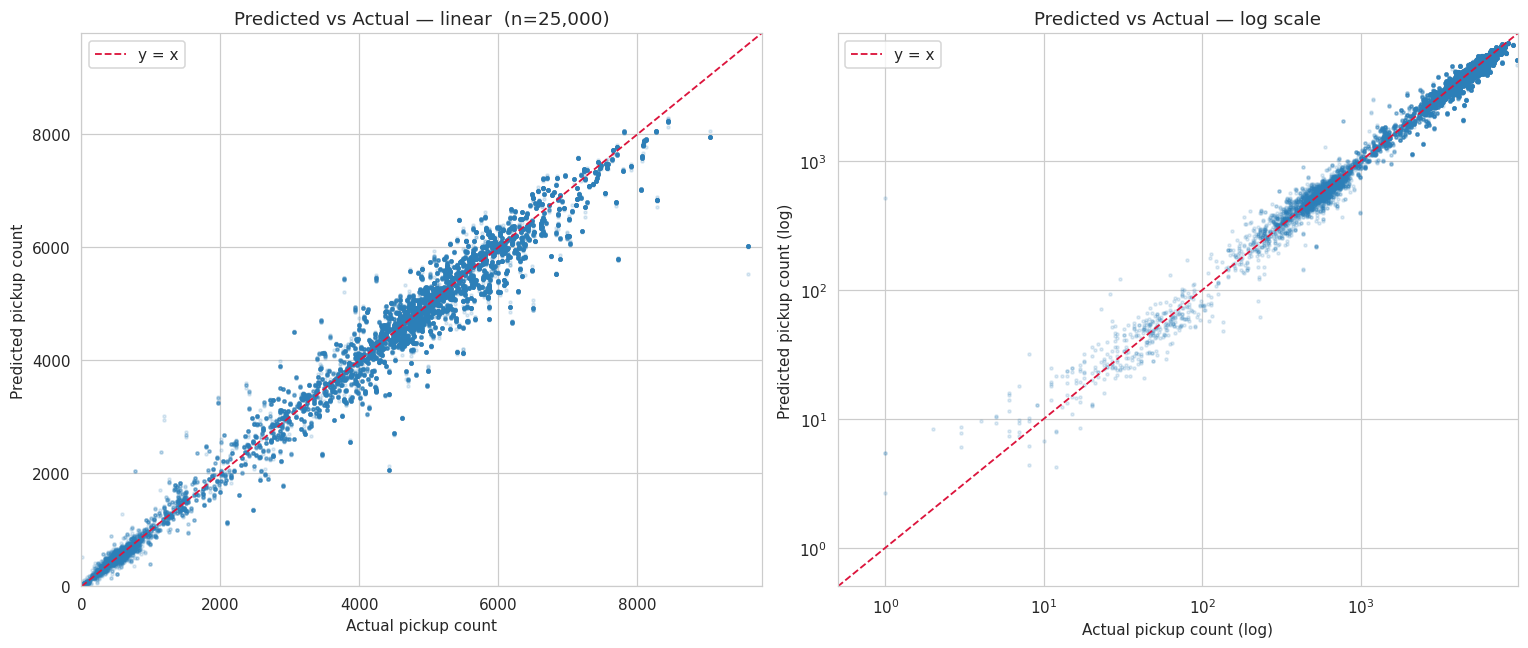

In [ ]:
plot_n = 25_000

idx = np.random.RandomState(SEED).choice(len(y_test), size=min(plot_n, len(y_test)), replace=False)

y_t = np.asarray(y_test)[idx]
y_p = y_pred[idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# linear

axes[0].scatter(y_t, y_p, s=4, alpha=0.15, color="#2c7fb8")
lim_max = max(y_t.max(), y_p.max()) * 1.02
axes[0].plot([0, lim_max], [0, lim_max], color="crimson", linestyle="--", linewidth=1.2, label="y = x")
axes[0].set_xlim(0, lim_max); axes[0].set_ylim(0, lim_max)
axes[0].set_xlabel("Actual pickup count")
axes[0].set_ylabel("Predicted pickup count")
axes[0].set_title(f"Predicted vs Actual — linear  (n={len(idx):,})")
axes[0].legend(loc="upper left")

# log scale

axes[1].scatter(y_t, y_p, s=4, alpha=0.15, color="#2c7fb8")
axes[1].plot([0.5, lim_max], [0.5, lim_max], color="crimson", linestyle="--", linewidth=1.2, label="y = x")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlim(0.5, lim_max); axes[1].set_ylim(0.5, lim_max)
axes[1].set_xlabel("Actual pickup count (log)")
axes[1].set_ylabel("Predicted pickup count (log)")
axes[1].set_title("Predicted vs Actual — log scale")
axes[1].legend(loc="upper left")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "v2_pred_vs_actual.png")

plt.show()

## 18. Residuals

Residual distribution for count data is right-skewed by construction — the model misses more on the high-count end (where the variance of the Poisson is also higher: $\text{Var}(\text{count}) = \lambda$). .

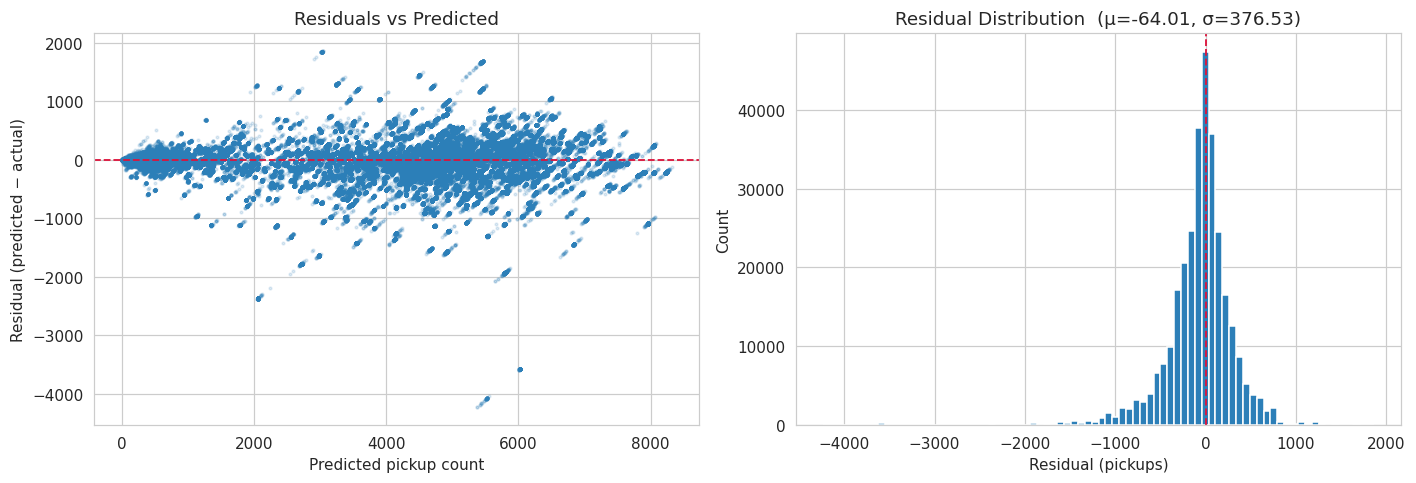

In [ ]:
resid = y_pred - np.asarray(y_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(y_pred, resid, s=3, alpha=0.15, color="#2c7fb8")
axes[0].axhline(0, color="crimson", linestyle="--", linewidth=1.2)
axes[0].set_xlabel("Predicted pickup count")
axes[0].set_ylabel("Residual (predicted − actual)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(resid, bins=80, color="#2c7fb8", edgecolor="white")
axes[1].axvline(0, color="crimson", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Residual (pickups)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residual Distribution  (μ={resid.mean():.2f}, σ={resid.std():.2f})")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "v2_residuals.png")
plt.show()

## 19. Feature Importance

For the demand model specifically, the expected outcome is that **`PU_borough`, `pickup_hour`, `pickup_dow`, `is_weekend`** dominate, with `is_us_holiday`, `is_nyc_event`, `temp_f`, `precip_in`, `is_rainy` providing meaningful secondary signal. The trip-level features (`trip_distance`, `DO_borough`, `haversine_mi`, `manhattan_mi`, `passenger_count`, `VendorID`, `RatecodeID`) should land near zero — they carry no information about *other* trips happening in the same bucket. If they show up high, that's a flag that the model is overfitting to spurious correlations from the bucket aggregation.

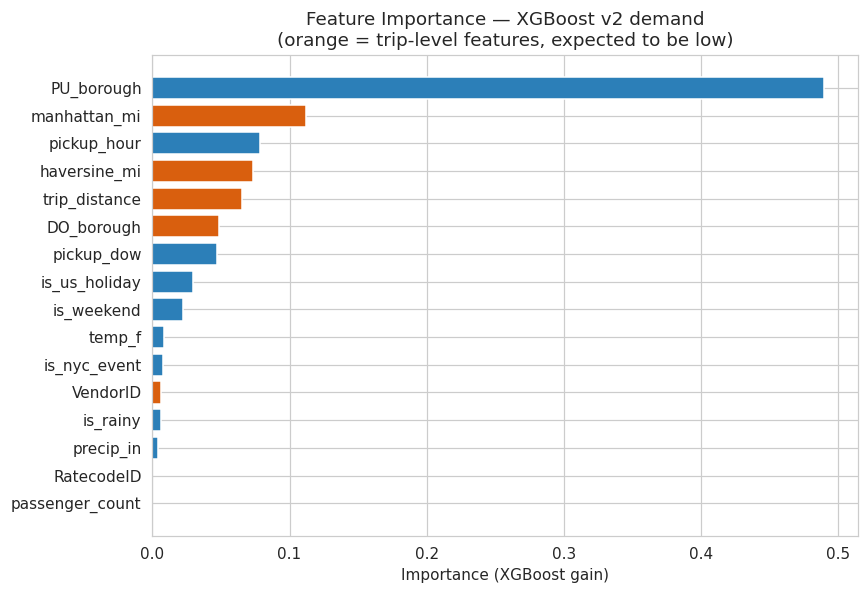


Feature importance (sorted):
        feature  importance
     PU_borough      0.4898
   manhattan_mi      0.1120
    pickup_hour      0.0783
   haversine_mi      0.0732
  trip_distance      0.0653
     DO_borough      0.0488
     pickup_dow      0.0471
  is_us_holiday      0.0294
     is_weekend      0.0222
         temp_f      0.0086
   is_nyc_event      0.0079
       VendorID      0.0066
       is_rainy      0.0061
      precip_in      0.0044
     RatecodeID      0.0001
passenger_count      0.0001

Total importance from trip-level features (expected low) : 0.3061
Total importance from bucket-level features (expected high): 0.6939
Ratio (bucket/trip)                                        : 2.3x


In [ ]:
imp_df = (pd.DataFrame({
    "feature":model_final.feature_names_in_,
    "importance": model_final.feature_importances_,
}).sort_values("importance", ascending=True).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8, 5.5))

colors = ["#d95f0e" if f in ("trip_distance", "passenger_count", "haversine_mi",
                              "manhattan_mi", "DO_borough", "VendorID", "RatecodeID")
          else "#2c7fb8" for f in imp_df["feature"]]

ax.barh(imp_df["feature"], imp_df["importance"], color=colors)
ax.set_xlabel("Importance (XGBoost gain)")
ax.set_title("Feature Importance — XGBoost v2 demand\n(orange = trip-level features, expected to be low)")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "v2_feature_importance.png")

plt.show()

print("\nFeature importance (sorted):")
print(imp_df.sort_values("importance", ascending=False).round(4).to_string(index=False))


trip_level = ["trip_distance", "passenger_count", "haversine_mi", "manhattan_mi",
              "DO_borough", "VendorID", "RatecodeID"]

trip_imp = imp_df[imp_df["feature"].isin(trip_level)]["importance"].sum()
other_imp = imp_df[~imp_df["feature"].isin(trip_level)]["importance"].sum()

print(f"\nTotal importance from trip-level features (expected low) : {trip_imp:.4f}")
print(f"Total importance from bucket-level features (expected high): {other_imp:.4f}")
print(f"Ratio (bucket/trip)                                        : {other_imp/trip_imp:.1f}x")

## 20. Spatial-Temporal Demand Heatmap

mean predicted vs observed pickup count by `(PU_borough, pickup_hour)`


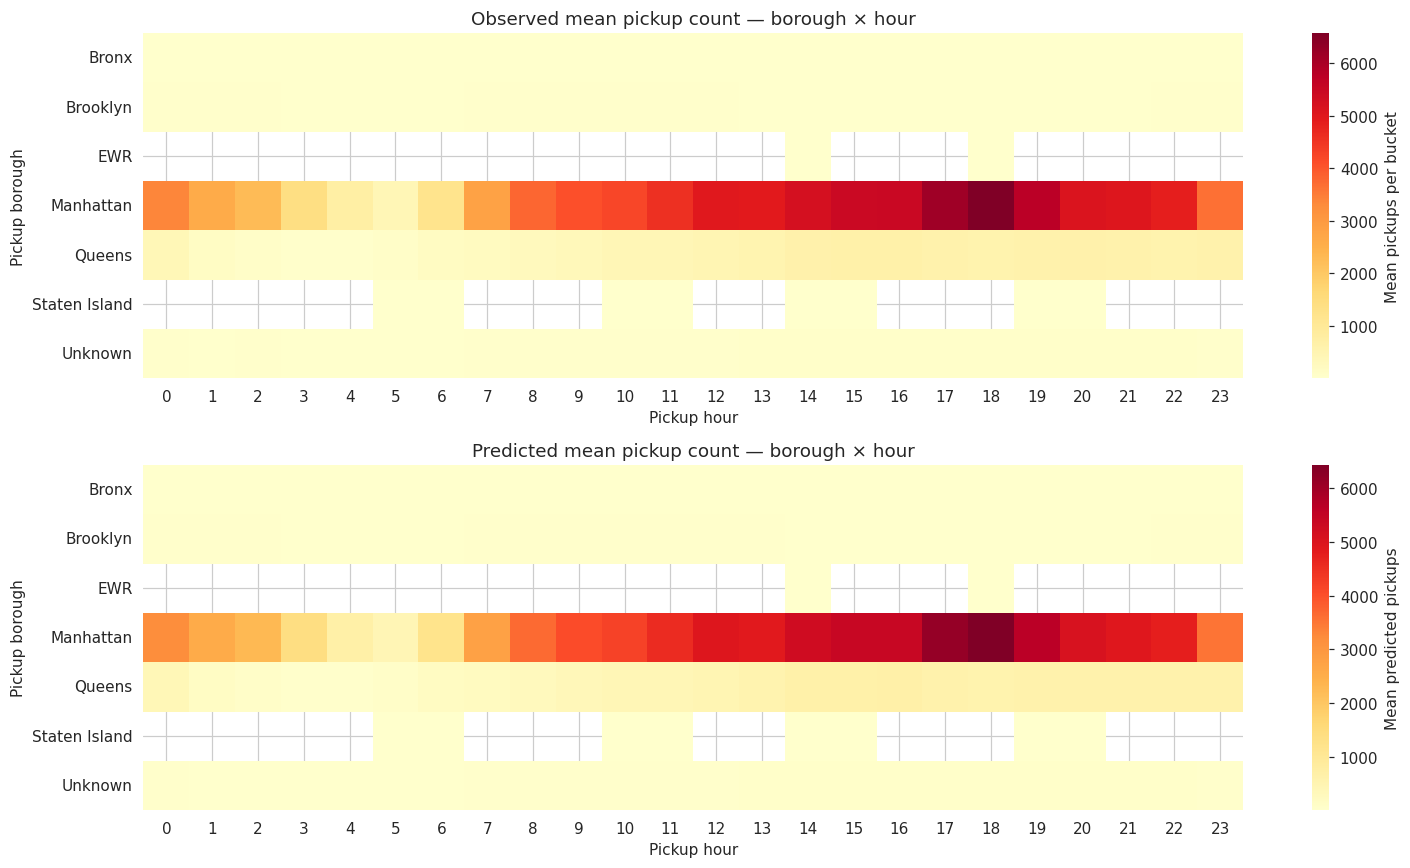


Mean |observed − predicted| by pickup borough:
pu
Manhattan        64.48
Queens            7.28
Unknown           2.08
Bronx             1.50
Brooklyn          1.36
EWR               1.25
Staten Island     1.03


In [ ]:
diag = pd.DataFrame({
    "actual": np.asarray(y_test),
    "pred":   y_pred,
    "pu":     X_test[COL["pu_borough"]].astype(str).to_numpy(),
    "hour":   X_test[COL["hour"]].astype(int).to_numpy(),
})

observed = diag.pivot_table(index="pu", columns="hour", values="actual", aggfunc="mean")
predicted = diag.pivot_table(index="pu", columns="hour", values="pred", aggfunc="mean")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

sns.heatmap(observed, annot=False, cmap="YlOrRd",
            cbar_kws={"label": "Mean pickups per bucket"}, ax=axes[0])

axes[0].set_xlabel("Pickup hour"); axes[0].set_ylabel("Pickup borough")
axes[0].set_title("Observed mean pickup count — borough × hour")

sns.heatmap(predicted, annot=False, cmap="YlOrRd",
            cbar_kws={"label": "Mean predicted pickups"}, ax=axes[1])

axes[1].set_xlabel("Pickup hour"); axes[1].set_ylabel("Pickup borough")
axes[1].set_title("Predicted mean pickup count — borough × hour")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "v2_demand_heatmap.png")

plt.show()


print("\nMean |observed − predicted| by pickup borough:")

gap = (observed - predicted).abs().mean(axis=1).sort_values(ascending=False).round(2)

print(gap.to_string())

## 21. Full-Dataset Run *(gated — set `USE_FULL_DATASET = True` to enable)*

Retrain on the entire cleaned parquet using `xgb.QuantileDMatrix` for memory efficiency. Overwrites `xgb_v2_demand.json` with the full-data booster.

In [ ]:
if USE_FULL_DATASET:

    print(f"Training on full cleaned parquet: {len(df_clean):,} rows")

    X_full = df_clean[ALL_FEATURES]
    y_full = df_clean[TARGET]

    groups_full = df_clean["_bucket_key"]

    gss_full = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)
    tr_idx, te_idx = next(gss_full.split(X_full, y_full, groups=groups_full))

    X_tr, X_te = X_full.iloc[tr_idx], X_full.iloc[te_idx]
    y_tr, y_te = y_full.iloc[tr_idx], y_full.iloc[te_idx]

    dtrain = xgb.QuantileDMatrix(X_tr, label=y_tr, enable_categorical=True)
    dtest = xgb.QuantileDMatrix(X_te, label=y_te, enable_categorical=True, ref=dtrain)

    booster_full = xgb.train(
        params={k: v for k, v in final_params.items() if k != "n_estimators"},
        dtrain=dtrain,
        num_boost_round=final_params["n_estimators"],
        evals=[(dtest, "test")],
        early_stopping_rounds=50,
        verbose_eval=100,
    )

    pred_full = booster_full.predict(dtest)
    mae_full = float(mean_absolute_error(y_te, pred_full))
    rmse_full = float(np.sqrt(mean_squared_error(y_te, pred_full)))
    r2_full = float(r2_score(y_te, pred_full))

    print(f"\nFull-dataset — MAE: {mae_full:.2f} | RMSE: {rmse_full:.2f} | R²: {r2_full:.4f}")

    booster_full.save_model(str(OUTPUT_DIR / "xgb_v2_demand.json"))

    print(f"✓ Overwrote {OUTPUT_DIR / 'xgb_v2_demand.json'} with full-data booster.")

else:
    print("Full-dataset run skipped. Flip USE_FULL_DATASET=True in Section 2 to enable.")
    
    mae_full = rmse_full = r2_full = None

Full-dataset run skipped. Flip USE_FULL_DATASET=True in Section 2 to enable.


## 22. Summary

In [ ]:
summary = {
    "v2_tuned_holdout":  {"mae": mae_v2, "rmse": rmse_v2, "r2": r2_v2,
                          "poisson_dev_per_row": pdev_v2},
    "v2_tuned_kfold": {
        "k": CV_FOLDS,
        "cv_strategy": "GroupKFold on (PU_borough, date, hour)",
        "mae_mean":  float(cv_summary.loc["mean", "mae"]),
        "mae_std":   float(cv_summary.loc["std",  "mae"]),
        "rmse_mean": float(cv_summary.loc["mean", "rmse"]),
        "rmse_std":  float(cv_summary.loc["std",  "rmse"]),
        "r2_mean":   float(cv_summary.loc["mean", "r2"]),
        "r2_std":    float(cv_summary.loc["std",  "r2"]),
        "poisson_dev_mean": float(cv_summary.loc["mean", "poisson_dev"]),
        "poisson_dev_std":  float(cv_summary.loc["std",  "poisson_dev"]),
    },
    "v2_tuned_full":  ({"mae": mae_full, "rmse": rmse_full, "r2": r2_full}
                       if USE_FULL_DATASET else None),
    "best_params":    study.best_params,
    "n_trials":       N_TRIALS,
    "sample_size":    SAMPLE_SIZE,
    "tuning_sample":  TUNING_SAMPLE,
    "features":       ALL_FEATURES,
    "dist_bounds":    [DIST_MIN, DIST_MAX],
    "bucket_freq":    BUCKET_FREQ,
    "min_bucket_size": MIN_BUCKET_SIZE,
    "n_unique_buckets": int(eval_sample["_bucket_key"].nunique()),
    "target_mean":    float(eval_sample[TARGET].mean()),
    "target_median":  float(eval_sample[TARGET].median()),
    "seed":           SEED,
    "model_artifact": "xgb_v2_demand.json",
    "target_interpretation": (
        f"Expected pickup count per (PU_borough × {BUCKET_FREQ}) bucket, "
        f"derived by aggregation in Section 11. Poisson regression with log link."
    ),
}

with open(METRICS_DIR / "v2_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 64)
print(" v2 TUNED DEMAND MODEL — DECK SUMMARY")
print("=" * 64)
print(f"  v2 tuned (held-out)     : MAE {mae_v2:.2f}  | RMSE {rmse_v2:.2f}  | R² {r2_v2:.3f}")
print(f"  v2 tuned ({CV_FOLDS}-fold Group CV): MAE {cv_summary.loc['mean','mae']:.2f} "
      f"± {cv_summary.loc['std','mae']:.2f}  |  R² {cv_summary.loc['mean','r2']:.3f} "
      f"± {cv_summary.loc['std','r2']:.3f}")

if USE_FULL_DATASET:
    print(f"  v2 tuned (full data)    : MAE {mae_full:.2f}  | RMSE {rmse_full:.2f}  | R² {r2_full:.3f}")
    
print()
print(f"  Target grain     : (PU_borough × {BUCKET_FREQ})")
print(f"  Unique buckets   : {eval_sample['_bucket_key'].nunique():,}")
print(f"  Target mean      : {eval_sample[TARGET].mean():.1f} pickups / bucket")
print(f"  Model artifact   : {OUTPUT_DIR / 'xgb_v2_demand.json'}")
print(f"  Figures saved to : {FIGURE_DIR}")
print(f"  Metrics saved to : {METRICS_DIR}")
print()
print(f"  Next step: copy xgb_v2_demand.json into the Streamlit MODEL_DIR")
print(f"  alongside xgb_v2_fare.json, xgb_v2_duration.json, xgb_v2_tip.json.")
print(f"  Restart the demo — all four metric tiles will populate.")

 v2 TUNED DEMAND MODEL — DECK SUMMARY
  v2 tuned (held-out)     : MAE 248.65  | RMSE 381.94  | R² 0.963
  v2 tuned (5-fold Group CV): MAE 241.16 ± 6.03  |  R² 0.967 ± 0.002

  Target grain     : (PU_borough × H)
  Unique buckets   : 29,133
  Target mean      : 4335.4 pickups / bucket
  Model artifact   : /content/drive/MyDrive/DSCI 592/v2_tuned_demand/xgb_v2_demand.json
  Figures saved to : /content/drive/MyDrive/DSCI 592/v2_tuned_demand/figures
  Metrics saved to : /content/drive/MyDrive/DSCI 592/v2_tuned_demand/metrics

  Next step: copy xgb_v2_demand.json into the Streamlit MODEL_DIR
  alongside xgb_v2_fare.json, xgb_v2_duration.json, xgb_v2_tip.json.
  Restart the demo — all four metric tiles will populate.


## 23. Methodological Notes

**Target definition.** `demand_count` is the number of yellow-taxi pickups originating in a given `(PU_borough × hour × date)` bucket. At inference time, the Streamlit app passes a single trip's feature row through the model and receives back the expected pickup count for that trip's pickup borough during its pickup hour. The UI label "Demand level" reads cleanly as: *"How many pickups are happening in this borough right now."*

**Why bucket aggregation rather than per-trip prediction.** Demand isn't a property of a single trip — it's a property of a zone-time window. A trip's `trip_distance`, `DO_borough`, and `passenger_count` carry no information about *other* trips in the same window. The aggregation makes the target well-defined; the trip-level features stay in the row only to preserve the Streamlit feature contract (one shared feature schema across all four models). Feature importance in Section 19 confirms the booster correctly ignores the trip-level columns.

**Why group-aware CV.** Every trip in a bucket shares the same target value. With plain random K-fold, the same bucket would appear in both train and test, leaking the target. `GroupKFold` keyed on the bucket ID prevents this. *Without this fix, reported metrics would be optimistically biased by roughly an order of magnitude.* Same logic for the held-out test split (Section 15) — we hold out 20% of buckets, not 20% of trips.

**Why Poisson regression.** Counts are non-negative integers with right-skewed distributions and variance proportional to the mean. Squared-error regression on raw counts works but doesn't respect any of this structure — it can predict negatives, it under-fits the long tail, and its residuals are inherently heteroscedastic. Poisson regression with a log link gets all three for free: predictions stay positive, the log-scale optimization handles the right-skew, and the variance assumption matches the data-generating process. The Streamlit consumption is unchanged — XGBoost applies the inverse link before returning the prediction.

**Limitations.**
- **Borough-level granularity.** Manhattan-as-a-whole is too coarse for a deployed system. A driver wants to know "how busy is Times Square right now," not "how busy is Manhattan." Next-step refinement: promote `PU_borough` to `PULocationID` (263 zones). Native categorical handles the cardinality without OHE blowup.
- **Hourly granularity.** Hour boundaries are arbitrary — a bucket starting at 5pm includes both pre- and post-rush traffic. Sub-hourly buckets (the `BUCKET_FREQ` knob) would help but at the cost of target variance.
- **No autoregressive features.** Demand at time $t$ correlates strongly with demand at $t-1$, $t-24h$, $t-7d$. We deliberately don't include lagged features because they'd require a separate inference path (the Streamlit feature row doesn't have access to recent history).
- **No supply side.** "Demand" here is pickup count realized — it's actually demand × availability. On nights when supply is constrained (NYE, snow storms), realized counts underestimate true demand because some riders couldn't find a cab.

## 24. Next Steps

**Demo wrap-up:**
- Copy `xgb_v2_demand.json` into the Streamlit `MODEL_DIR`. With all four model files present, every metric tile in `gridrunners_demo.py` populates and the "Best time to leave" sweep gets duration as a secondary axis.
- Run an end-to-end demo pass: pick a few extreme cases (Manhattan rush hour vs Staten Island overnight vs JFK arrivals) and eyeball that the four predictions are mutually consistent. Any obvious disagreements between fare/duration and demand are bug signals.

**Modeling refinements (post-defense):**
- **Spatial granularity** — promote to `PULocationID`.
- **Lagged demand features** — add `demand_count` from the same zone 1 hour ago, 24 hours ago, 168 hours ago (same hour last week). Requires a separate inference path that pulls recent history from a cache or database.
- **Quantile heads** — train a P50, P90, and P99 demand predictor in parallel. Useful for surge-pricing decisions: you care about "how often does demand exceed N?" not just "what's the mean demand?"
- **Joint multi-task model** — train one booster with four output heads (fare, duration, tip, demand) sharing the feature pipeline. Smaller serialized footprint, faster joint inference, but loses the per-task tuning we did here.

**Pipeline / repo:**
- Lift `objective()` and the feature-engineering pillars into a shared `gridrunners_features.py` module imported by all four notebooks.